# Monthly-to-Daily Pipeline

Many applications need daily synthetic flows, but the most robust generation
methods operate at a monthly scale. SynHydro's **pipelines** chain a monthly
generator with a temporal disaggregator in a single interface.

`KirschNowakPipeline` combines the Kirsch monthly bootstrap with the Nowak
KNN disaggregator. You provide daily observed data; it handles the internal
monthly aggregation and disaggregation automatically.

> **Note:** Run this notebook from the `examples/` directory. Figures are saved to `figures/08_pipeline/` and data outputs to `outputs/08_pipeline/` (both are gitignored).

In [1]:
from pathlib import Path

FIG_DIR = Path("figures") / "08_pipeline"
OUT_DIR = Path("outputs") / "08_pipeline"
SHARED_DIR = Path("outputs") / "shared"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
SHARED_DIR.mkdir(parents=True, exist_ok=True)

## Generate daily synthetic flows

Daily generation is the most expensive step in these tutorials, so the result
is cached in `outputs/shared/`. If you have run this notebook before, the
saved ensemble is loaded instead of re-generated (delete the file to force a
fresh run).

In [2]:
import synhydro

Q_daily = synhydro.load_example_data()

shared_path = SHARED_DIR / "kn_daily_ensemble.hdf5"
if shared_path.exists():
    daily_ensemble = synhydro.Ensemble.from_hdf5(shared_path)
else:
    pipeline = synhydro.KirschNowakPipeline()
    pipeline.fit(Q_daily)
    daily_ensemble = pipeline.generate(n_realizations=10, n_years=30, seed=42)
    daily_ensemble.to_hdf5(shared_path, compression="gzip")

In [3]:
Q_syn_daily = daily_ensemble.data_by_realization[0]
print(Q_syn_daily.shape)  # (~10957 days x n_sites)

(10957, 4)


> **Tip (Single-site alternative):**
> ```python
> pipeline = synhydro.ThomasFieringNowakPipeline()
> pipeline.fit(Q_daily.iloc[:, [0]])
> ```

## Visualize

Plot a one-year window (starting at the synthetic period start) to inspect daily variability:

Only 10 realizations; percentile bands may be unreliable. Recommend N >= 30 for stable estimates.


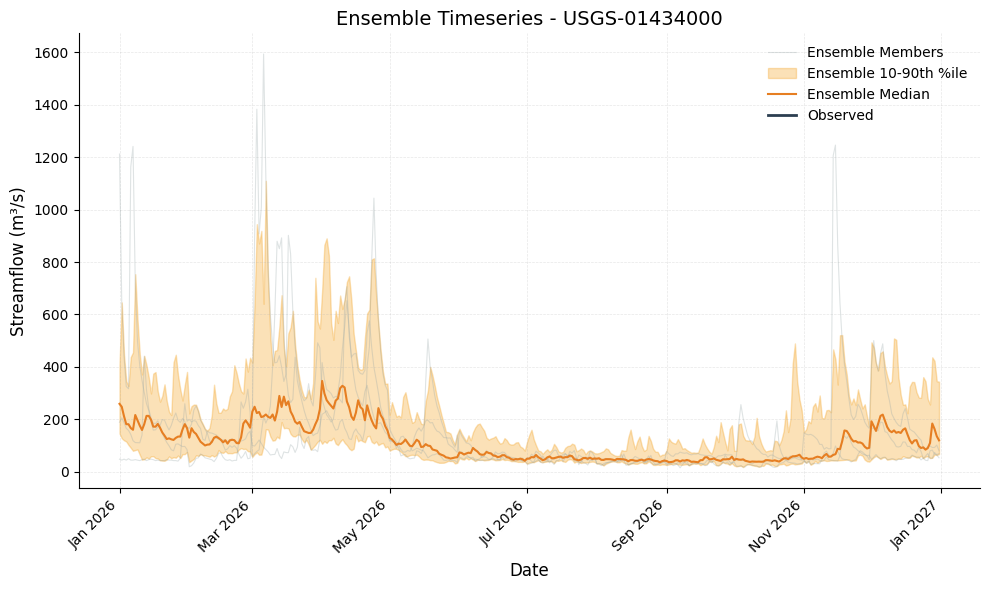

In [4]:
import pandas as pd
from synhydro.plotting import plot_timeseries

site = Q_daily.columns[0]
syn_start = daily_ensemble.data_by_realization[0].index[0]
start = str(syn_start.date())
end = str((syn_start + pd.DateOffset(years=1) - pd.Timedelta(days=1)).date())

fig, ax = plot_timeseries(
    daily_ensemble,
    observed=Q_daily[site],
    start_date=start,
    end_date=end,
    show_members=3,
)
fig.savefig(FIG_DIR / "daily_timeseries.png", dpi=150, bbox_inches="tight")

## Next steps

- **Drought analysis** on synthetic flows - [Tutorial 07](../07_drought_analysis/)
- **Ensemble validation** - [Tutorial 05](../05_verification/)
- **Algorithm details** - [Kirsch Bootstrap](../../algorithms/kirsch/),
  [Nowak Disaggregation](../../algorithms/nowak_disaggregation/)

---

**Previous:** [Drought Analysis (SSI)](../07_drought_analysis/)